In [9]:
#TASK 1
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix
#loading data set in pandas dataframe
print("Step 1: Loading data...")
df = pd.read_csv("hotel_booking.csv")

# Safely drop rows where the answer is blank
df = df.dropna(subset=['is_canceled'])

print("Step 2: Preparing the features...")
# This safely checks if the cheating columns exist before dropping them!
columns_to_drop = ['is_canceled', 'reservation_status', 'reservation_status_date']
safe_drop_list = [col for col in columns_to_drop if col in df.columns]
#target variable y and seperate feature x
X = df.drop(columns=safe_drop_list)
y = df['is_canceled']

numeric_cols = X.select_dtypes(include=['number']).columns
text_cols = X.select_dtypes(include=['object', 'str']).columns

X[numeric_cols] = X[numeric_cols].fillna(0)
X[text_cols] = X[text_cols].fillna('Unknown')

print("Step 3: turning test into numbers")
X_encoded = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.3, random_state=42)

print("Step 4: model training")
model = RandomForestClassifier(random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

print("Step 5: making predictions...")
y_pred = model.predict(X_test)
y_pred_probability = model.predict_proba(X_test)[:, 1]

print("\n--- BASELINE RESULTS ---")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_probability))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))



 

Step 1: Loading data...
Step 2: Preparing the features...
Step 3: turning test into numbers
Step 4: model training
Step 5: making predictions...

--- BASELINE RESULTS ---
Accuracy: 0.9824928798793768
ROC-AUC: 0.9969304808639194
Confusion Matrix:
 [[22219   281]
 [  346 12968]]


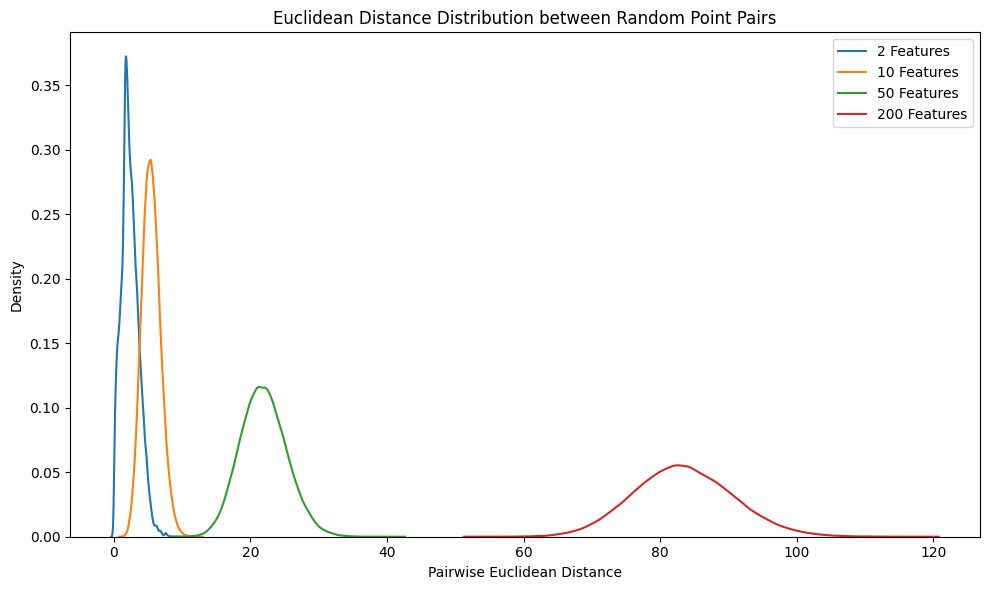

None


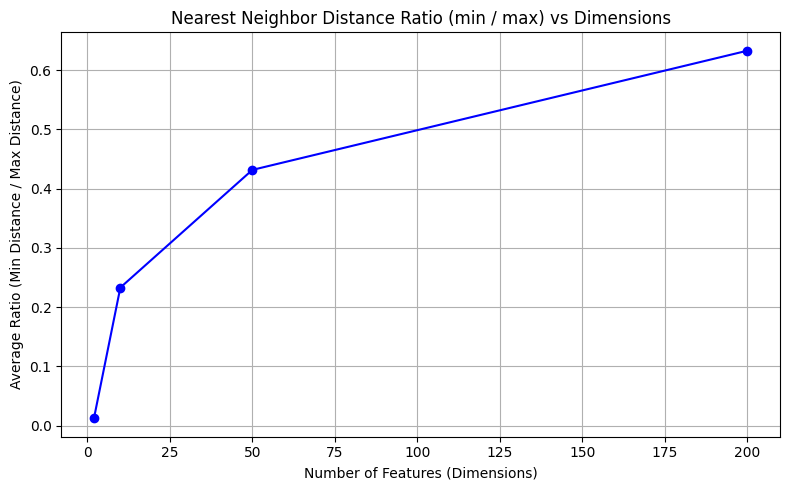

None


In [2]:
#task 2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification
from scipy.spatial.distance import pdist, squareform
#feature size we want to test
dimensions = [2, 10, 50, 200]
ratios= []

plt.figure(figsize=(10,6))

for d in dimensions:
    x, _ = make_classification(n_samples=500, n_features=d, n_informative=max(2, d//2),n_redundant=0, random_state=42)
    #making fake data and generating 500 random data points

    #calculating pairwise euclidean distances
    distances = pdist(x, metric="euclidean")

    #ploting distribution of these distances
    sns.kdeplot(distances, label=f'{d} Features')

    #calculate min and max
    matrix = squareform(distances)
    np.fill_diagonal(matrix, np.inf)
    min_dists = matrix.min(axis = 1)

    np.fill_diagonal(matrix, 0)
    max_dists = matrix.max(axis=1)
    #calculating the ratio
    avg_ratio = np.mean(min_dists / max_dists)
    ratios.append(avg_ratio)
#plot 1
plt.title("Euclidean Distance Distribution between Random Point Pairs")
plt.xlabel('Pairwise Euclidean Distance')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
print(plt.show())
#plot 2
plt.figure(figsize=(8,5))
plt.plot(dimensions , ratios , marker='o', linestyle='-', color='b')
plt.title('Nearest Neighbor Distance Ratio (min / max) vs Dimensions')
plt.xlabel('Number of Features (Dimensions)')
plt.ylabel('Average Ratio (Min Distance / Max Distance)')
plt.grid(True)
plt.tight_layout()
print(plt.show())



--- Original data stats ---


,Feature,Mean,Std,IQR
0,lead_time,104.0113,106.8625,142.00
1,stays_in_weekend_nights,0.9276,0.9986,2.00
2,stays_in_week_nights,2.5003,1.9082,2.00
3,adults,1.8564,0.5792,0.00
4,previous_cancellations,0.0871,0.8443,0.00
5,adr,101.8289,50.5319,56.71



--- minmaxscaler stats ---


,Feature,Mean,Std,IQR
0,lead_time_minmax,0.1411,0.1450,0.1927
1,stays_in_weekend_nights_minmax,0.0488,0.0526,0.1053
2,stays_in_week_nights_minmax,0.0500,0.0382,0.0400
3,adults_minmax,0.0338,0.0105,0.0000
4,previous_cancellations_minmax,0.0034,0.0325,0.0000
5,adr_minmax,0.0200,0.0093,0.0105



--- StandardScaler Stats ---


,Feature,Mean,Std,IQR
0,lead_time_standard,0.0,1.0,1.3288
1,stays_in_weekend_nights_standard,-0.0,1.0,2.0028
2,stays_in_week_nights_standard,0.0,1.0,1.0481
3,adults_standard,-0.0,1.0,0.0000
4,previous_cancellations_standard,0.0,1.0,0.0000
5,adr_standard,0.0,1.0,1.1223



--- RobustScaler Stats ---


,Feature,Mean,Std,IQR
0,lead_time_robust,0.2466,0.7526,1.0
1,stays_in_weekend_nights_robust,-0.0362,0.4993,1.0
2,stays_in_week_nights_robust,0.2501,0.9541,1.0
3,adults_robust,-0.1436,0.5792,0.0
4,previous_cancellations_robust,0.0871,0.8443,0.0
5,adr_robust,0.1291,0.8911,1.0


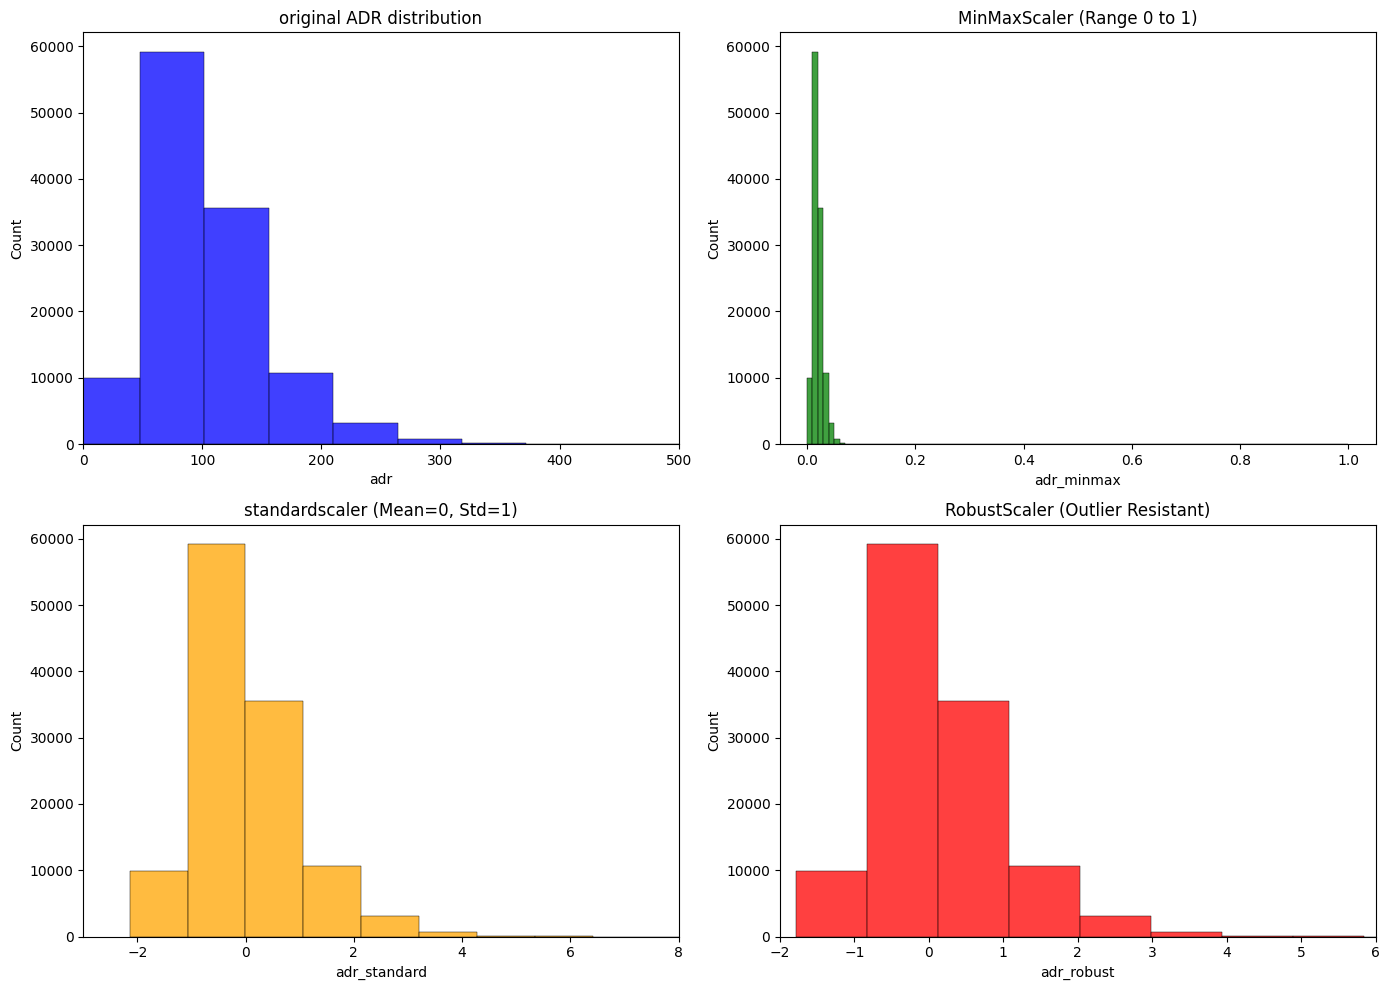

In [3]:
#TASK 3

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, Binarizer
# loading data 
df = pd.read_csv('hotel_booking.csv')

#picking at least 6 numeic columns 
features = ['lead_time', 'stays_in_weekend_nights', 'stays_in_week_nights','adults', 'previous_cancellations',"adr"]

df[features] = df[features].fillna(df[features].median())
#binning/ discretization
df["lead"] = pd.qcut(df['lead_time'], q=4 , labels=['short', 'medium', 'long', 'very long'])

df['adrr'] = pd.cut(df['adr'], bins=[-np.inf, 50, 100, 150, np.inf], labels=['Budget', 'Economy', 'Standard' , 'Premium'])

#binarization
Binarizer = Binarizer(threshold=100.0)
df['high_value_customer'] = Binarizer.fit_transform(df[['adr']])

#compare scaling methods
#We are testing three different ways to shrink these numbers down so they are easy to compare
scaler_minmax = MinMaxScaler()
scaler_standard = StandardScaler()
scaler_robust = RobustScaler()

df_minmax = pd.DataFrame(scaler_minmax.fit_transform(df[features]), columns=[f"{c}_minmax" for c in features])
df_standard = pd.DataFrame(scaler_standard.fit_transform(df[features]), columns=[f"{c}_standard" for c in features])
df_robust = pd.DataFrame(scaler_robust.fit_transform(df[features]), columns=[f"{c}_robust" for c in features])

#summary stats change

def cal_stats(data, cols, name=""):
    stats = []
    for col in cols:
        mean = data[col].mean()
        std = data[col].std()
        iqr = data[col].quantile(0.75) - data[col].quantile(0.25)
        stats.append([col, mean , std, iqr])
    print(f"\n--- {name} ---")
    display(pd.DataFrame(stats, columns=['Feature', 'Mean', 'Std', 'IQR']).round(4))

   #printing out the statistical comparisons

cal_stats(df , features , "Original data stats")
cal_stats(df_minmax, [f"{c}_minmax" for c in features], "minmaxscaler stats")
cal_stats(df_standard, [f"{c}_standard" for c in features], "StandardScaler Stats")
cal_stats(df_robust, [f"{c}_robust" for c in features], "RobustScaler Stats")

#visual distributions
fig, axes = plt.subplots(2,2 , figsize=(14,10))

#orignal
sns.histplot(df['adr'], bins=100, ax=axes[0,0], color='blue')
axes[0,0].set_title('original ADR distribution')# average daily rate
axes[0,0].set_xlim(0, 500)
#minmax
sns.histplot(df_minmax['adr_minmax'], bins=100, ax=axes[0,1], color='green')
axes[0,1].set_title('MinMaxScaler (Range 0 to 1)')

#standard
sns.histplot(df_standard['adr_standard'], bins=100, ax=axes[1,0], color='orange')
axes[1,0].set_title('standardscaler (Mean=0, Std=1)')
axes[1,0].set_xlim(-3, 8)
#robust
sns.histplot(df_robust['adr_robust'], bins=100, ax=axes[1,1], color='red')
axes[1,1].set_title('RobustScaler (Outlier Resistant)')
axes[1,1].set_xlim(-2, 6)

plt.tight_layout()
plt.show()

In [4]:
#TASK 4
import pandas as pd
import numpy as np
import time
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.metrics import accuracy_score , f1_score, roc_auc_score
# loading the data
df = pd.read_csv('hotel_booking.csv')

target = 'is_canceled'
features = ['lead_time', 'stays_in_weekend_nights', 'stays_in_week_nights', 
                    'adults', 'previous_cancellations', 'adr','children', 'babies', 'total_of_special_requests']
    
df_clean = df.dropna(subset=[target] + features).copy()
df_sample = df_clean.sample(n=15000, random_state=42)

X = df_sample[features]
y = df_sample[target]
#split into training and testing sets
X_train , X_test , y_train , y_test = train_test_split(X,y, test_size=0.3, random_state=42)

def test_knn(name, obj, metric_name):
    if obj is not None:
        X_train_scale = obj.fit_transform(X_train)
        X_test_scale = obj.transform(X_test)
    else:
        X_train_scale = X_train
        X_test_scale = X_test

    #setting up knn model
    knn = KNeighborsClassifier(n_neighbors=5, metric=metric_name)

    #model to tract how long it takes
    start_time = time.time()
    knn.fit(X_train_scale, y_train)
    predictions = knn.predict(X_test_scale)
    run_time = time.time() - start_time
    probabilities = knn.predict_proba(X_test_scale)[:, 1]

#calculate accuracy
    accuracy = accuracy_score(y_test, predictions)
    f1 = f1_score(y_test, predictions)
    roc = roc_auc_score(y_test, probabilities)
    print(f"Scaler {name : <15} | Distance: {metric_name} | Accuracy {accuracy: .4f} | time {run_time: .2f}| F1: {f1:.4f} | ROC-AUC: {roc:.4f}s")

# runt he required tests
print("knn performance camparison")
test_knn("none (raw data)", None, "euclidean")
test_knn("StandardScaler", StandardScaler(), "euclidean")
test_knn("RobustScaler", RobustScaler(), "euclidean")
test_knn("StandardScaler", StandardScaler(),"manhattan" )
test_knn("RobustScaler", RobustScaler(), "manhattan")


knn performance camparison
Scaler none (raw data) | Distance: euclidean | Accuracy  0.7442 | time  0.03| F1: 0.5861 | ROC-AUC: 0.7767s
Scaler StandardScaler  | Distance: euclidean | Accuracy  0.7840 | time  0.17| F1: 0.6429 | ROC-AUC: 0.8081s
Scaler RobustScaler    | Distance: euclidean | Accuracy  0.7847 | time  0.10| F1: 0.6426 | ROC-AUC: 0.8085s
Scaler StandardScaler  | Distance: manhattan | Accuracy  0.7862 | time  0.21| F1: 0.6458 | ROC-AUC: 0.8121s
Scaler RobustScaler    | Distance: manhattan | Accuracy  0.7867 | time  0.12| F1: 0.6463 | ROC-AUC: 0.8131s


In [5]:
#TASK 5
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler, PowerTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

#loading data
df = pd.read_csv("hotel_booking.csv")
target = "is_canceled"
#defing features and target
skewed = ["lead_time", "adr"]
standard = ['stays_in_weekend_nights', "stays_in_week_nights", "adults", "previous_cancellations"]

#drop any missing targets if any
df_clean = df.dropna(subset=[target]).copy()

X = df_clean[skewed + standard]
y = df_clean[target]
#it fills the score with the median value
skewed_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())
])

standard_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ('skewed_pipeline', skewed_transformer, skewed),
        ('standard_pipeline', standard_transformer, standard)

    ])
#pipeline model
fin_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))

])

cv_scores = cross_val_score(fin_pipeline , X , y , cv = 5, scoring='accuracy')
print(f"accuracy for each of the 5 folds {np.round(cv_scores, 4)}")
print(f"mean cv accuracy {cv_scores.mean():.4f}")
print(f"standard deviation {cv_scores.std():.4f}")


accuracy for each of the 5 folds [0.6328 0.6215 0.6743 0.6249 0.7116]
mean cv accuracy 0.6530
standard deviation 0.0349


In [10]:
#task 6
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder

#load data
df = pd.read_csv('hotel_booking.csv')
#computer only understands numbers 0 and 1s . so we have to use dictionary to change name into number
months = {'January': 1, 'February': 2, 'March': 3, 'April': 4, 'May': 5, 'June': 6, 
             'July': 7, 'August': 8, 'September': 9, 'October': 10, 'November': 11, 'December': 12}
# creating seasons. this helps the model to see seasonal booking trends
df['arrival_month'] = df["arrival_date_month"].map(months)

df["arrival_quarter"] = np.ceil(df['arrival_month']/ 3).astype(int)

df['arrival_str'] = df['arrival_date_year'].astype(str) + '-' + df['arrival_month'].astype(str) + '-' + df['arrival_date_day_of_month'].astype(str)
df['arrivial_date'] = pd.to_datetime(df['arrival_str'],format='%Y-%m-%d', errors='coerce')

df['is_weekend'] = df['arrivial_date'].dt.dayofweek.isin([5,6]).astype(int)
# We use OneHotEncoder to create new columns of 1s and 0s for each category
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

categorical_cols = ["deposit_type", 'customer_type']

encoded_data = encoder.fit_transform(df[categorical_cols])
encoded_columns = encoder.get_feature_names_out(categorical_cols)
# Put those new 1s and 0s into a clean table (DataFrame)
df_encoded = pd.DataFrame(encoded_data, columns=encoded_columns)

df = pd.concat([df.reset_index(drop=True), df_encoded.reset_index(drop=True)], axis=1)
print("\nclean features added ")
print(f"Data/Time features : 'arrivial_month', 'arrival_quarter', 'is_weekend_arrival' ")
print(f"{list(encoded_columns)}")


clean features added 
Data/Time features : 'arrivial_month', 'arrival_quarter', 'is_weekend_arrival' 
['deposit_type_No Deposit', 'deposit_type_Non Refund', 'deposit_type_Refundable', 'deposit_type_nan', 'customer_type_Contract', 'customer_type_Group', 'customer_type_Transient', 'customer_type_Transient-Party', 'customer_type_nan']


In [7]:
#task 7
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, roc_auc_score


# Load the actual dataset

df = pd.read_csv('hotel_booking.csv')

# Define features (X) and target (y)
# We do this BEFORE splitting
X = df.drop('is_canceled', axis=1)
y = df['is_canceled']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)




X_train = X_train.copy()
X_test = X_test.copy()

#  Use train-derived statistics for any imputation so we don't leak test info
impute_cols = ['adults', 'children', 'babies', 'adr', 'stays_in_weekend_nights',
               'stays_in_week_nights', 'total_of_special_requests', 'lead_time']

# Filter to only include columns that actually exist in the dataframe
impute_cols = [col for col in impute_cols if col in X_train.columns]

train_medians = X_train[impute_cols].median()
X_train[impute_cols] = X_train[impute_cols].fillna(train_medians)
X_test[impute_cols] = X_test[impute_cols].fillna(train_medians) 

#  Basic constructed features (ratios / totals / flags)
def add_basic_features(df):
    df['total_nights'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']
    df['total_guests'] = df['adults'] + df['children'] + df['babies']
    df['price_per_person'] = df['adr'] / (df['adults'] + df['children'] + 1)
    df['special_requests_rate'] = df['total_of_special_requests'] / (df['total_nights'] + 1)
    df['is_family'] = ((df['children'].fillna(0) + df['babies'].fillna(0)) > 0).astype(int)
    df['total_revenue'] = df['adr'] * df['total_nights']
    return df

X_train = add_basic_features(X_train)
X_test = add_basic_features(X_test)


avg_adr_by_country = X_train.groupby('country')['adr'].mean().to_dict()
avg_adr_by_country_hotel = X_train.groupby(['country', 'hotel'])['adr'].mean().to_dict()

# Map with safe defaults (use global train mean where missing)
global_train_adr_mean = X_train['adr'].mean()
X_train['avg_adr_by_country'] = X_train['country'].map(avg_adr_by_country).fillna(global_train_adr_mean)
X_test['avg_adr_by_country'] = X_test['country'].map(avg_adr_by_country).fillna(global_train_adr_mean)

# Mapping multi-index keys safely
X_train['avg_adr_by_country_hotel'] = X_train.set_index(['country','hotel']).index.map(lambda k: avg_adr_by_country_hotel.get(k, global_train_adr_mean))
X_test['avg_adr_by_country_hotel'] = X_test.set_index(['country','hotel']).index.map(lambda k: avg_adr_by_country_hotel.get(k, global_train_adr_mean))

# 4) Interaction features (simple multiplications)
X_train['adr_times_lead'] = X_train['adr'] * X_train['lead_time']
X_test['adr_times_lead'] = X_test['adr'] * X_test['lead_time']
X_train['price_x_requests'] = X_train['price_per_person'] * X_train['special_requests_rate']
X_test['price_x_requests'] = X_test['price_per_person'] * X_test['special_requests_rate']

# 5) PolynomialFeatures (degree=2)
poly_cols = ['lead_time', 'adr']
poly = PolynomialFeatures(degree=2, include_bias=False)
poly.fit(X_train[poly_cols])

poly_train = pd.DataFrame(poly.transform(X_train[poly_cols]),
                          columns=poly.get_feature_names_out(poly_cols),
                          index=X_train.index)
poly_test = pd.DataFrame(poly.transform(X_test[poly_cols]),
                         columns=poly.get_feature_names_out(poly_cols),
                         index=X_test.index)

# Add polynomial-derived features explicitly
X_train['lead_time_squared'] = poly_train['lead_time^2']
X_test['lead_time_squared'] = poly_test['lead_time^2']
X_train['adr_squared'] = poly_train['adr^2']
X_test['adr_squared'] = poly_test['adr^2']

# Handle interaction naming (usually 'lead_time adr')
interaction_col = [c for c in poly_train.columns if ' ' in c][0]
X_train['lead_adr_interaction'] = poly_train[interaction_col]
X_test['lead_adr_interaction'] = poly_test[interaction_col]

# 6) Final evaluation
print("--- Testing Task 7 Features on Real Data ---")



# 1. Select only numbers/bools for the model
X_train_testable = X_train.select_dtypes(include=['number', 'bool']).fillna(0)
X_test_testable = X_test.select_dtypes(include=['number', 'bool']).fillna(0)


y_train_final = y_train.loc[X_train_testable.index].fillna(0).astype(int)
y_test_final = y_test.loc[X_test_testable.index].fillna(0).astype(int)

# 3. Double Check (This will print to your console to confirm cleaning worked)
print(f"Rows in X: {X_train_testable.shape[0]}, Rows in y: {len(y_train_final)}")
print(f"Any NaNs in X? {X_train_testable.isna().any().any()}")
print(f"Any NaNs in y? {y_train_final.isna().any()}")

# 4. Initialize and Fit
task7_model = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)

print("\nFitting model... please wait...")
task7_model.fit(X_train_testable, y_train_final)

# 5. Predict and Evaluate
t7_preds = task7_model.predict(X_test_testable)
t7_probs = task7_model.predict_proba(X_test_testable)[:, 1]

print("-" * 30)
print(f"Task 7 F1 Score: {f1_score(y_test_final, t7_preds):.4f}")
print(f"Task 7 ROC-AUC Score: {roc_auc_score(y_test_final, t7_probs):.4f}")

--- Testing Task 7 Features on Real Data ---
Rows in X: 95512, Rows in y: 95512
Any NaNs in X? False
Any NaNs in y? False

Fitting model... please wait...
------------------------------
Task 7 F1 Score: 0.9756
Task 7 ROC-AUC Score: 0.9961


In [8]:
#task 8
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif, chi2
from sklearn.preprocessing import MinMaxScaler

print("Starting Task 8: Feature Importance & Selection...\n")


X_train_num = X_train.select_dtypes(include=['number', 'bool']).fillna(0)
y_train = y_train.fillna(0)

#  Correlation Filter

print("--- 1. Dropping Copycats (Correlation Filter) ---")
corr_matrix = X_train_num.corr().abs()

# Find features that overlap by more than 85%
upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper_triangle.columns if any(upper_triangle[column] > 0.85)]

# Drop the redundant features
X_train_filtered = X_train_num.drop(columns=to_drop)
print(f"Dropped {len(to_drop)} redundant features: {to_drop}\n")

#  Random Forest
print("--- 2. Calculating Random Forest Importance ---")
rf = RandomForestClassifier(n_estimators=50, max_depth=7, random_state=42, n_jobs=-1)
rf.fit(X_train_filtered, y_train)
rf_scores = pd.Series(rf.feature_importances_, index=X_train_filtered.columns).sort_values(ascending=False)

# Mutual Information (Using a sample for speed)
print("--- 3. Calculating Mutual Information ---")
X_sample = X_train_filtered.sample(n=10500, random_state=42)
y_sample = y_train.loc[X_sample.index]
mi_values = mutual_info_classif(X_sample, y_sample, random_state=42)
mi_scores = pd.Series(mi_values, index=X_train_filtered.columns).sort_values(ascending=False)

# Chi-Square (Requires scaling to positive numbers first)
print("--- 4. Calculating Chi-Square ---")
scaler = MinMaxScaler()
X_scaled_df = pd.DataFrame(scaler.fit_transform(X_train_filtered), columns=X_train_filtered.columns)
chi_values, p_values = chi2(X_scaled_df, y_train.values)
chi_scores = pd.Series(chi_values, index=X_train_filtered.columns).sort_values(ascending=False)


print("\n=== THE TOP 15 LISTS ===")
print(f"\n[Random Forest Top 15]:\n{rf_scores.head(15).index.tolist()}")
print(f"\n[Mutual Info Top 15]:\n{mi_scores.head(15).index.tolist()}")
print(f"\n[Chi-Square Top 15]:\n{chi_scores.head(15).index.tolist()}")

# Combine lists, remove duplicates, and pick the ultimate Top 20
combined_winners = list(set(rf_scores.head(15).index.tolist() + 
                            mi_scores.head(15).index.tolist() + 
                            chi_scores.head(15).index.tolist()))

final_top_20 = combined_winners[:20]

print(f"\n=== THE ULTIMATE TOP 20 FEATURES ===")
print(final_top_20)

# Build our final datasets
X_train_final = X_train_filtered.filter(items=final_top_20)

# Safely filter the test set (ignoring any columns that don't exist)
X_test_final = X_test.filter(items=final_top_20) 
# Fill any missing columns in the test set with 0 just to be safe
for col in final_top_20:
    if col not in X_test_final.columns:
        X_test_final[col] = 0

print("\nTask 8 Complete! X_train_final and X_test_final are ready for modeling.")
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, roc_auc_score

print("--- Testing Final Top 20 Features (Task 8) ---")

# Safety check to fill any missing values so it doesn't crash
X_train_final_safe = X_train_final.select_dtypes(include=['number', 'bool']).fillna(0)
X_test_final_safe = X_test_final.select_dtypes(include=['number', 'bool']).fillna(0)
y_train_safe = y_train.fillna(0)
y_test_safe = y_test.fillna(0)

# Train the ultimate final model
final_model = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
final_model.fit(X_train_final_safe, y_train_safe)

# Get predictions
final_preds = final_model.predict(X_test_final_safe)
final_probs = final_model.predict_proba(X_test_final_safe)[:, 1]

# Calculate the final scores!
final_f1 = f1_score(y_test_safe, final_preds)
final_roc = roc_auc_score(y_test_safe, final_probs)

print(f"Final Task 8 F1 Score: {final_f1:.4f}")
print(f"Final Task 8 ROC-AUC Score: {final_roc:.4f}")

Starting Task 8: Feature Importance & Selection...

--- 1. Dropping Copycats (Correlation Filter) ---
Dropped 7 redundant features: ['total_nights', 'price_per_person', 'special_requests_rate', 'is_family', 'price_x_requests', 'lead_time_squared', 'lead_adr_interaction']

--- 2. Calculating Random Forest Importance ---
--- 3. Calculating Mutual Information ---
--- 4. Calculating Chi-Square ---

=== THE TOP 15 LISTS ===

[Random Forest Top 15]:
['id', 'avg_adr_by_country', 'lead_time', 'adr_times_lead', 'avg_adr_by_country_hotel', 'agent', 'total_of_special_requests', 'previous_cancellations', 'required_car_parking_spaces', 'arrival_date_year', 'booking_changes', 'adr_squared', 'adr', 'total_revenue', 'previous_bookings_not_canceled']

[Mutual Info Top 15]:
['id', 'adr_times_lead', 'lead_time', 'avg_adr_by_country_hotel', 'total_revenue', 'agent', 'adr', 'adr_squared', 'avg_adr_by_country', 'total_of_special_requests', 'previous_cancellations', 'required_car_parking_spaces', 'booking_ch